## CMPINF 2100 Week 08

### Realistic KMeans clustering example - using Penguins

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read data

In [2]:
penguins = sns.load_dataset('penguins')

In [4]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Preprocess
We need to standardize to REMOVE the magnitude and scale dominated by 1 variable

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


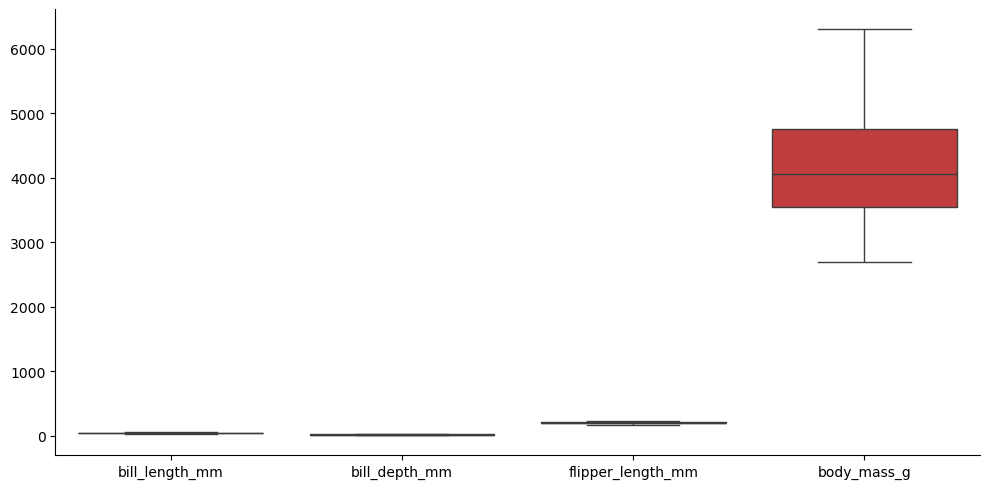

In [5]:
sns.catplot( data = penguins, kind='box', aspect=2)
plt.show()

Extract the numeric columns

In [6]:
pens_features = penguins.select_dtypes('number').copy()

Standardize the `StandardScaler()` method

In [8]:
from sklearn.preprocessing import StandardScaler

INITIALIZE, FIT, and Transform in 1 line of code!!

In [10]:
Xpens = StandardScaler().fit_transform( pens_features)

In [11]:
Xpens.shape

(344, 4)

In [12]:
type(Xpens)

numpy.ndarray

In [13]:
pens_features.shape

(344, 4)

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


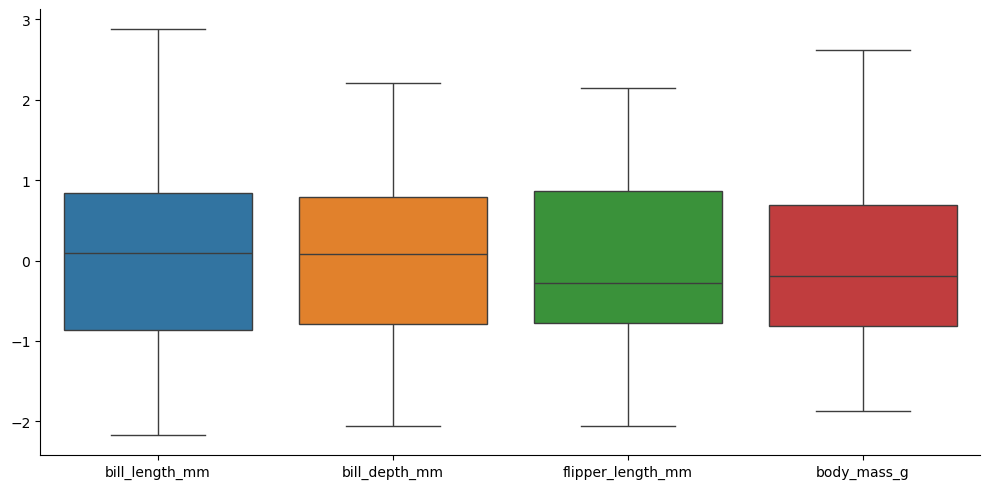

In [14]:
sns.catplot( data = pd.DataFrame(Xpens, columns=pens_features.columns), kind='box', aspect=2)
plt.show()

## KMeans

We know that there are 3 species in the penguins data set

In [15]:
penguins.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

However, let's follow GOOD practice and start out by applying KMeans with 2 clusters!!!

In [16]:
from sklearn.cluster import KMeans

INITIALIZE, FIT, and PREDICT in one line of code

In [18]:
clusters_2 = KMeans(n_clusters=2, random_state=121, n_init=25, max_iter=500).fit_predict( Xpens )

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

The reason why it is ALWAYS ciritical to FOLLOW the basic steps for EDA is we NEED TO always REMEMBER if out data set has MISSINGS!!!

In [19]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [26]:
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


## Drop Missings

The `StandardScaler()` method **Drops Missings** behind the scenes!!

The `KMeans` methods **Cannot Handle** missings!!

But the simplest and MOST BASIC action for dealing with MISSINGS is to REMOVE THEM!!!

REMOVING any row with at least 1 missing will return the **COMPLETE CASES**!!!

In [21]:
penguins_clean = penguins.dropna().copy()

In [22]:
penguins_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [23]:
penguins.shape

(344, 7)

In [24]:
penguins_clean.shape

(333, 7)

In [25]:
penguins_clean.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

We MUST now PREPROCESS the CLEANED dataframe and repeat the steps

In [27]:
pens_features_clean = penguins_clean.select_dtypes('number').copy()

Standardize the clean numeric columns

In [28]:
X = StandardScaler().fit_transform(pens_features_clean )

In [29]:
X.shape

(333, 4)

In [30]:
pens_features_clean.shape

(333, 4)

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


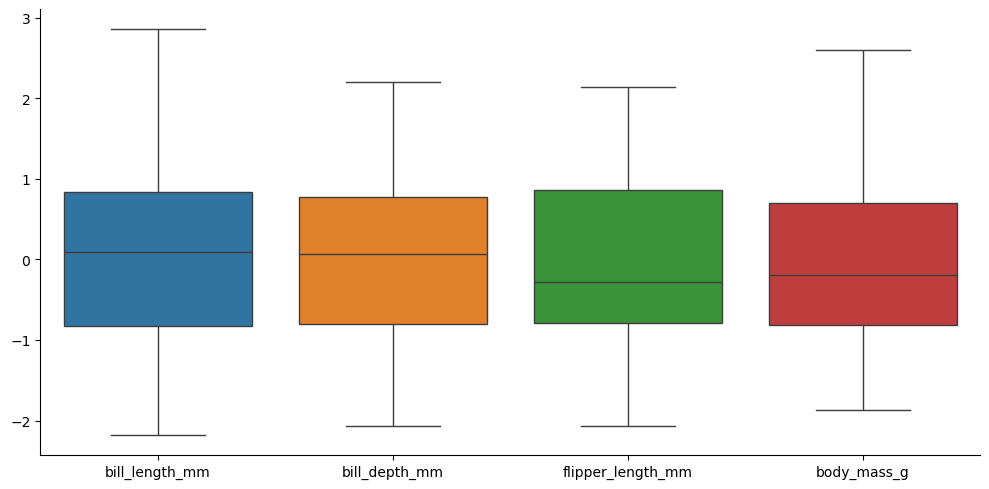

In [31]:
sns.catplot( data = pd.DataFrame(X, columns=pens_features_clean.columns), kind='box', aspect=2)
plt.show()

Now we can execute KMeans cluster

In [32]:
clusters_2 = KMeans(n_clusters=2, random_state=121, n_init=25, max_iter=500).fit_predict( X )

Assign the cluster labels to columns in a COPY of the cleaned data

In [34]:
penguins_clean_copy = penguins_clean.copy()

In [35]:
penguins_clean_copy['k2'] = pd.Series( clusters_2, index=penguins_clean_copy.index).astype('category')

In [36]:
penguins_clean_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            333 non-null    object  
 1   island             333 non-null    object  
 2   bill_length_mm     333 non-null    float64 
 3   bill_depth_mm      333 non-null    float64 
 4   flipper_length_mm  333 non-null    float64 
 5   body_mass_g        333 non-null    float64 
 6   sex                333 non-null    object  
 7   k2                 333 non-null    category
dtypes: category(1), float64(4), object(3)
memory usage: 21.2+ KB


In [37]:
penguins_clean_copy.k2.value_counts()

k2
0    214
1    119
Name: count, dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


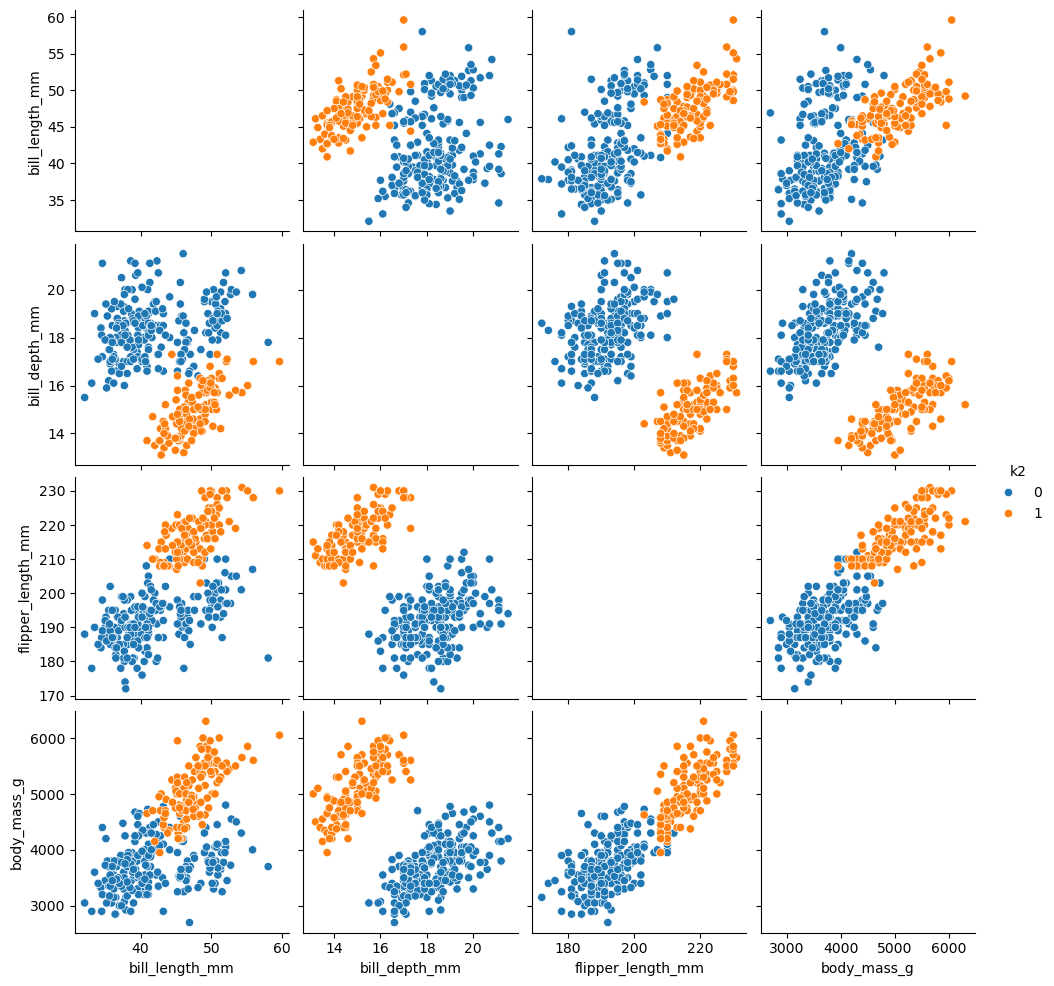

In [38]:
sns.pairplot(data = penguins_clean_copy, hue='k2', diag_kind={'common_norm': False})
plt.show()

### 3 Clusters

Since we know there are 3 species...let's now create 3 clusters and then Compare the clusters with the known groupings

In [39]:
clusters_3 = KMeans(n_clusters=3, random_state=121, n_init=25, max_iter=500).fit_predict( X )

In [40]:
penguins_clean_copy['k3'] = pd.Series( clusters_3, index=penguins_clean_copy.index).astype('category')

In [42]:
penguins_clean_copy.k3.value_counts()

k3
1    129
0    119
2     85
Name: count, dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


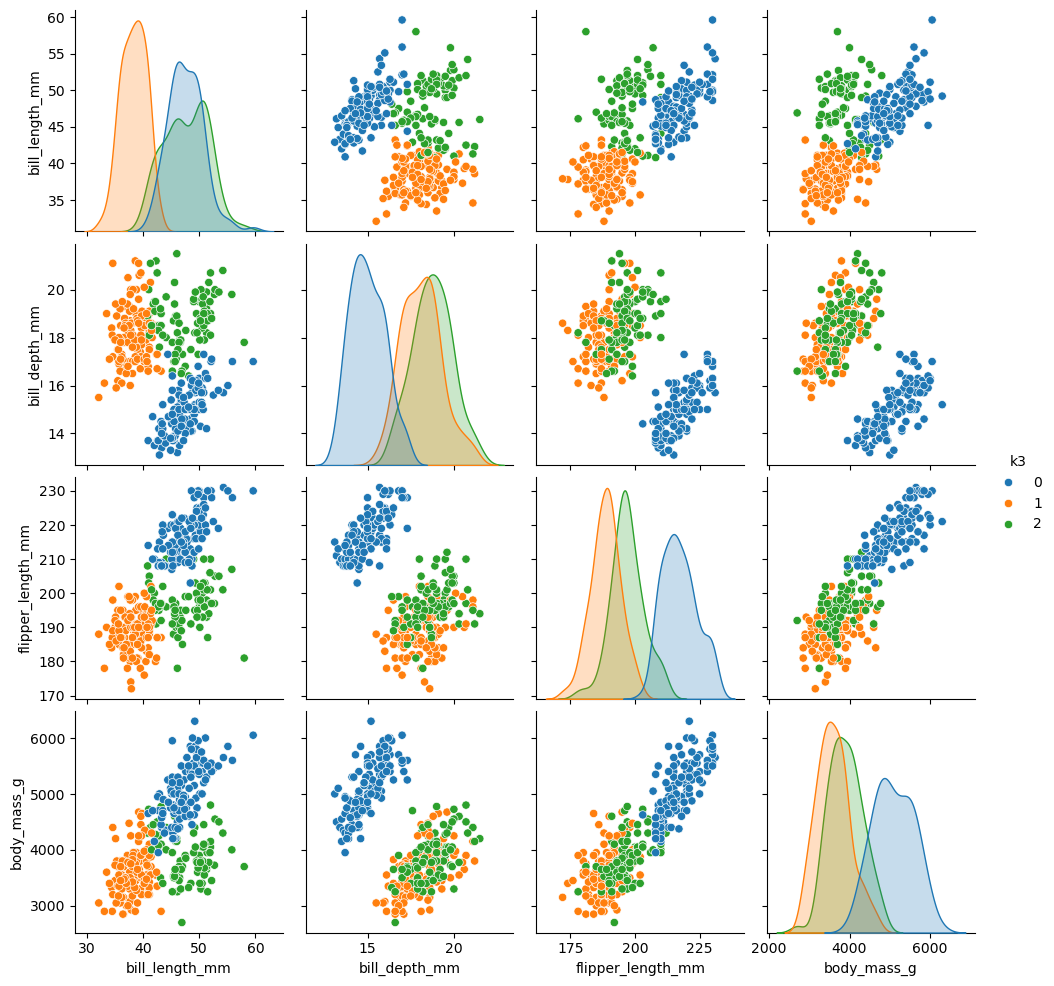

In [43]:
sns.pairplot( data = penguins_clean_copy, hue='k3', diag_kws={'common_norm':False})
plt.show()

Use the heatmap to visually show how well the CLUSTERS align with the KNOWN groping

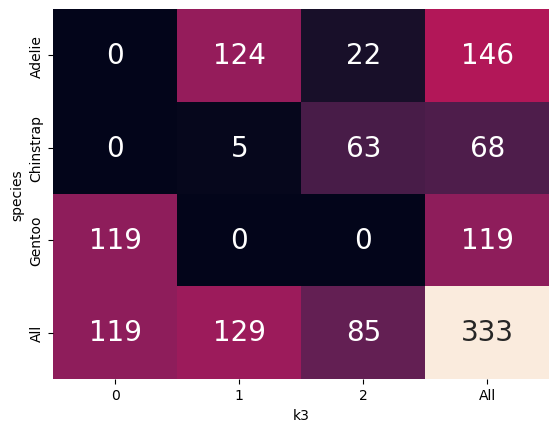

In [53]:
fig, ax = plt.subplots()
sns.heatmap( data = pd.crosstab( penguins_clean_copy.species, penguins_clean_copy.k3, margins=True ),
            annot=True, annot_kws={'fontsize': 20}, fmt='g',
            cbar=False,
            ax=ax)
plt.show()            

Look at the scatter plot between 2 of the vairables. Color by `k3` and set the marker shape by `species`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


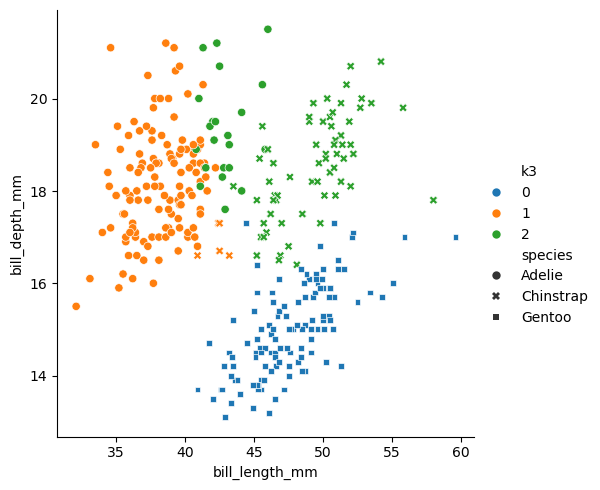

In [55]:
sns.relplot( data = penguins_clean_copy, x='bill_length_mm', y='bill_depth_mm', hue='k3', style='species')
plt.show()